In [1]:
import numpy as np
import pandas as pd
import corner
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
import matplotlib.cm as cm
from matplotlib.lines import Line2D

In [2]:
plt.rcParams['figure.max_open_warning'] = 0

plt.rcParams['text.usetex']        = True
    
# plt.rcParams['mathtext.fontset']  = 'stix'
# plt.rcParams['font.family']       = 'STIXGeneral'

plt.rcParams['font.size']         = 14
plt.rcParams['axes.linewidth']    = 1
plt.rcParams['axes.labelsize']    = plt.rcParams['font.size']
plt.rcParams['axes.titlesize']    = 1.5*plt.rcParams['font.size']
plt.rcParams['legend.fontsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['ytick.labelsize']   = plt.rcParams['font.size']
plt.rcParams['xtick.major.size']  = 3
plt.rcParams['xtick.minor.size']  = 3
plt.rcParams['xtick.major.width'] = 1
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.major.size']  = 3
plt.rcParams['ytick.minor.size']  = 3
plt.rcParams['ytick.major.width'] = 1
plt.rcParams['ytick.minor.width'] = 1

plt.rcParams['legend.frameon']             = False
plt.rcParams['legend.loc']                 = 'center left'
plt.rcParams['contour.negative_linestyle'] = 'solid'

In [3]:
df = pd.read_csv('../../data/SXS_Parameters.csv')
mask = df['catalog'] == 'SXS'
#https://arxiv.org/pdf/2001.09082
#Follows q=m1/m2>=1
# mass_ratio = m2/m1 <= 1
q = 1/df.loc[mask, 'q'].values
sxs_ids = df.loc[mask, 'ID'].astype(int).values
sxs_ids = [str(i).zfill(4) for i in sxs_ids]
chi1 = df.loc[mask, 'chi1z'].values
chi2 = df.loc[mask, 'chi2z'].values
a_0 = (q*chi1 + chi2)/(q+1)
a_12 = (q*chi1 - chi2)/(q+1)
X_12 = (q-1)/(q+1)
S_hats = a_0 + X_12*a_12

In [4]:
c3A, c3p, c4p, c2A, c2p = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
c3A_err, c3p_err, c4p_err, c2A_err, c2p_err = np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids)), np.zeros(len(sxs_ids))
full_data, S_hat, ids = [], [], []
for i, sxs_id in enumerate(sxs_ids):
    try:
        data = np.loadtxt(f'../../output/nc_qc_fits/nc_fits_sxs_equal-mass/SXS_{sxs_id}/Algorithm/posterior.dat')[:,[1,2,3,4,5]]
        c3A[i], c3p[i], c4p[i], c2A[i], c2p[i] = np.median(data, axis=0)
        c3A_err[i], c3p_err[i], c4p_err[i], c2A_err[i], c2p_err[i] = np.std(data, axis=0)
        full_data.append(data)
        S_hat.append(S_hats[i])
        ids.append(sxs_id)
    except:
        continue
c3A, c3p, c4p, c2A, c2p = c3A[c3A!=0], c3p[c3p!=0], c4p[c4p!=0], c2A[c2A!=0], c2p[c2p!=0]
c3A_err, c3p_err, c4p_err, c2A_err, c2p_err = c3A_err[c3A_err!=0], c3p_err[c3p_err!=0], c4p_err[c4p_err!=0], c2A_err[c2A_err!=0], c2p_err[c2p_err!=0]
S_hat = np.array(S_hat)

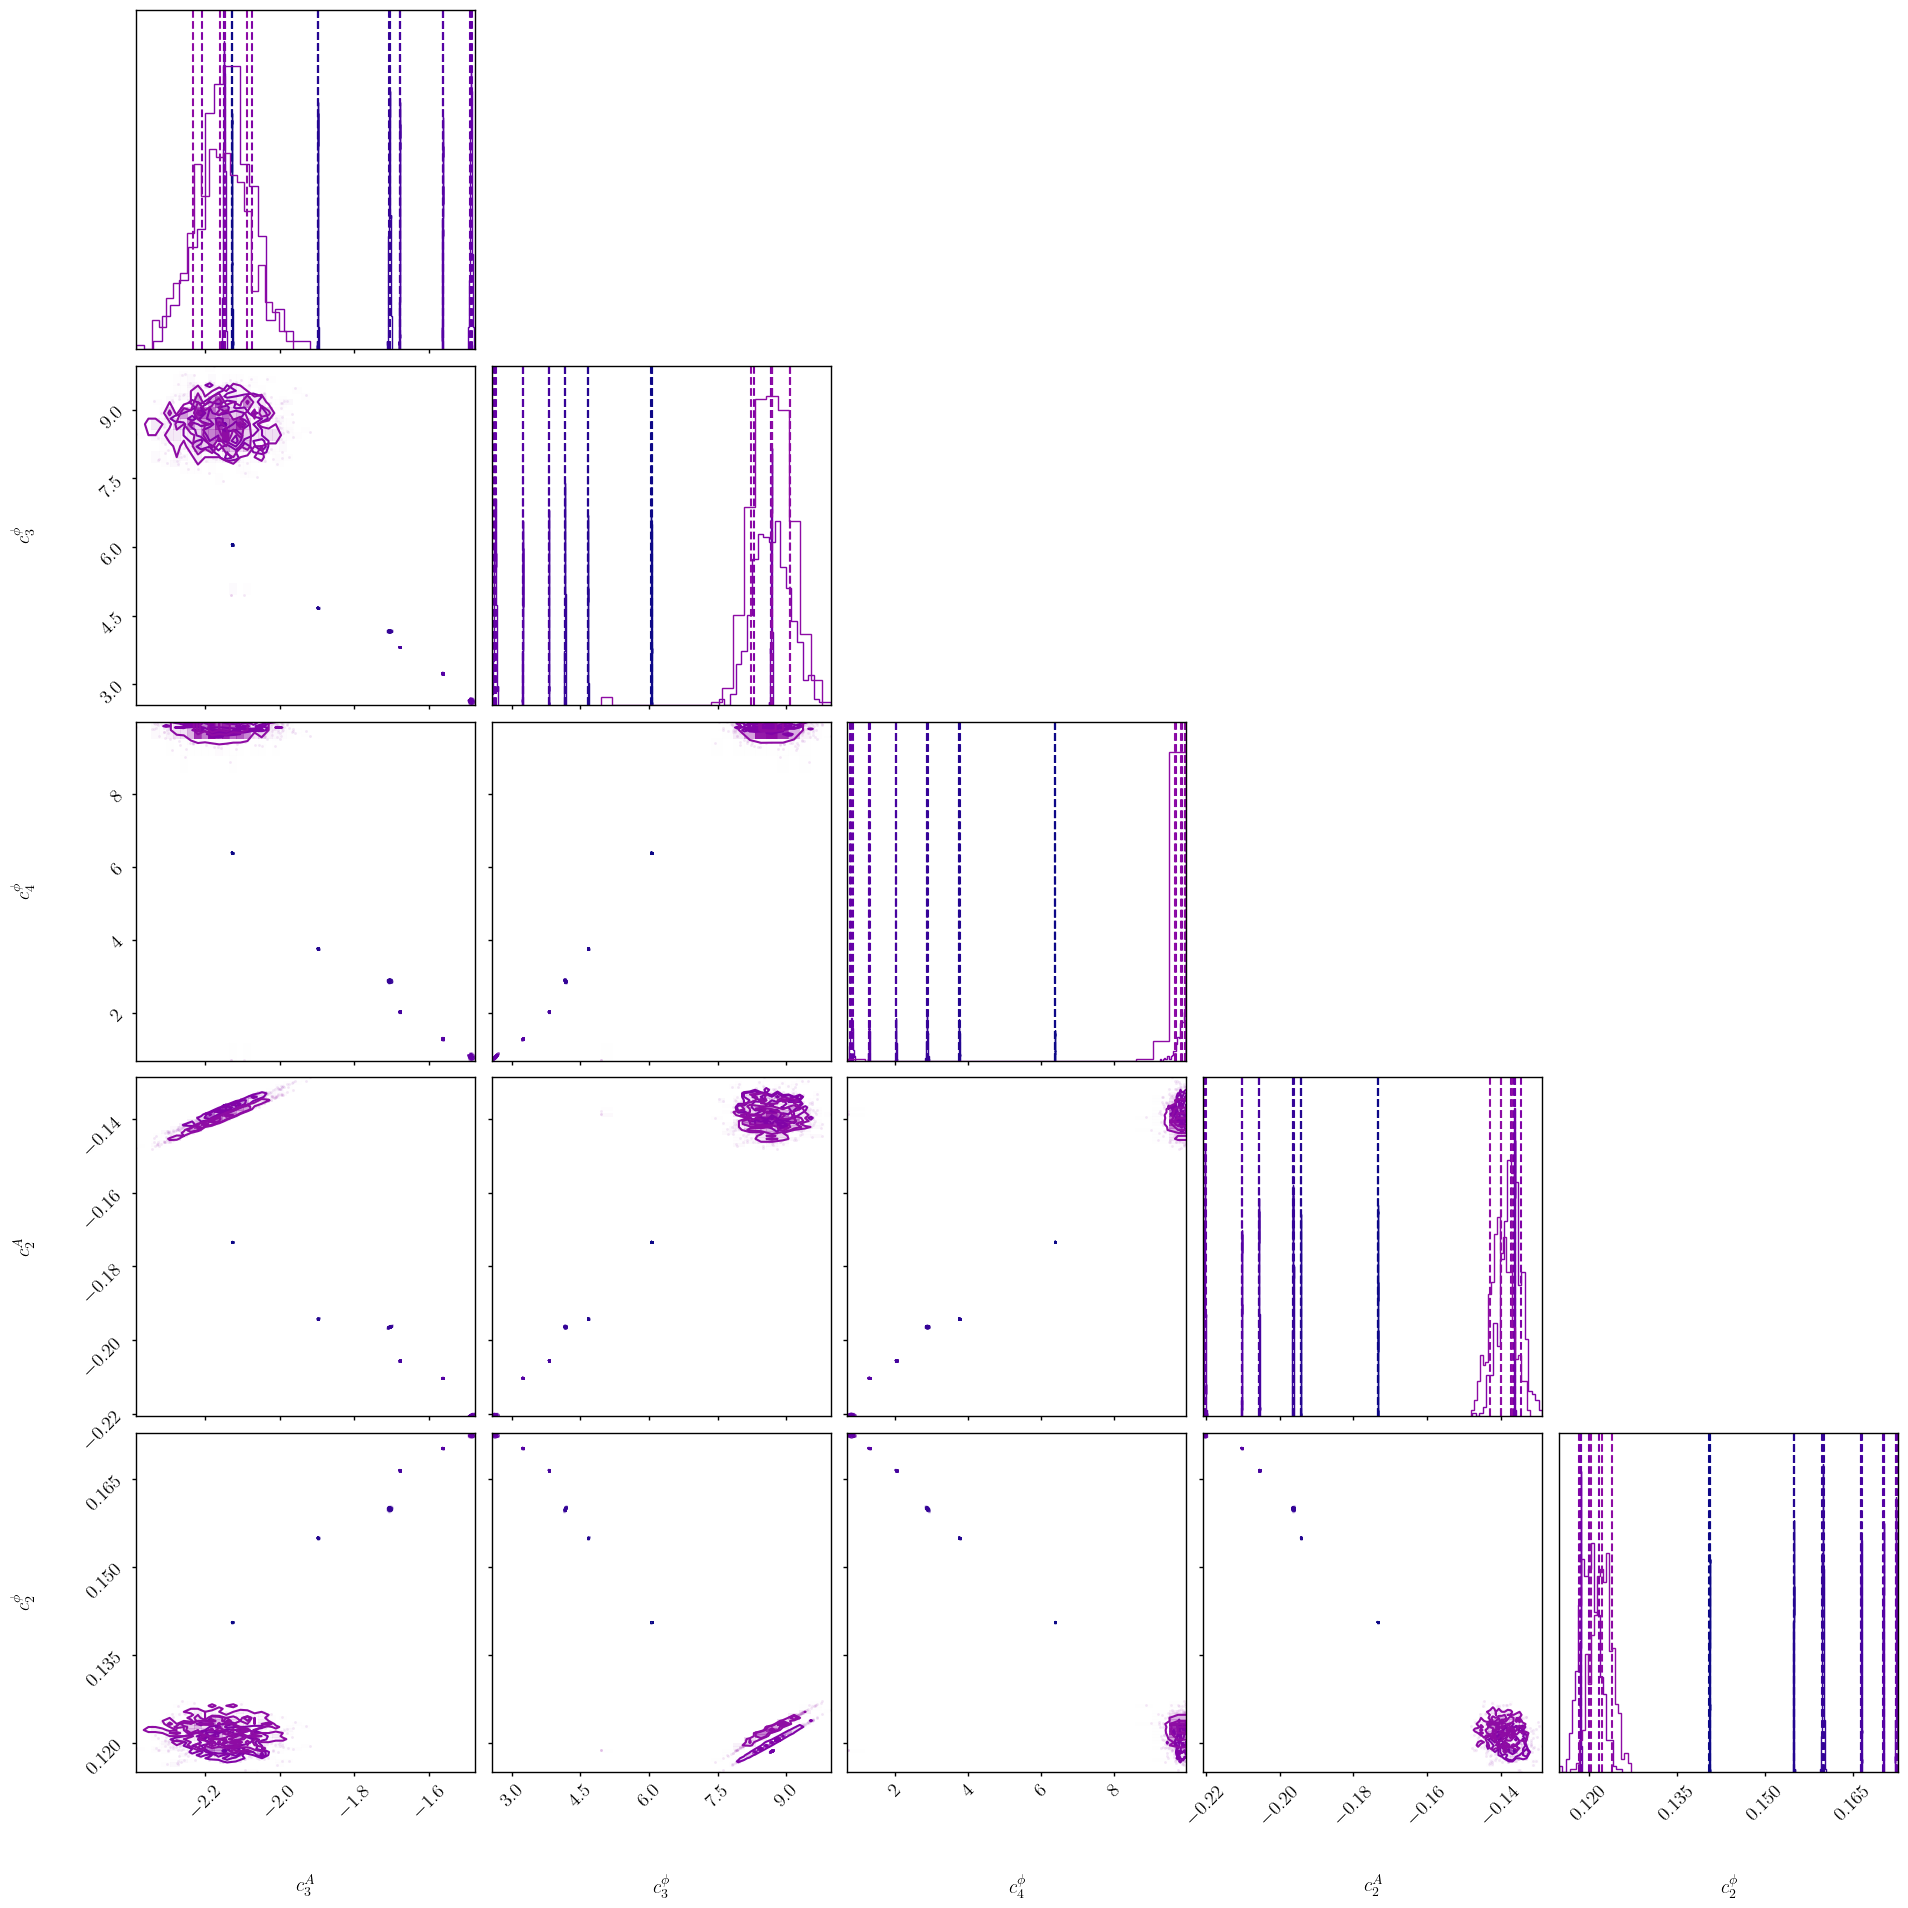

In [5]:
colors = [matplotlib.colormaps.get_cmap('plasma')(i) for i in np.linspace(0, 1, len(sxs_ids))]
ylabels = ['$c_3^A$', '$c_3^{\\phi}$', '$c_4^{\\phi}$', '$c_2^A$', '$c_2^{\\phi}$']
fig = corner.corner(full_data[0],
                    labels=ylabels,
                    color=colors[0],
                    quantiles=(0.16, 0.5, 0.84))
for i, data in enumerate(full_data):
    if i == 0:
        continue
    fig = corner.corner(data,
                        labels=ylabels,
                        color=colors[i],
                        quantiles=(0.16, 0.5, 0.84),
                        fig=fig)
fig.set_size_inches(20, 20)
plt.show()

In [6]:
mask = np.where(c3A != 0)
p2Achi, cov_p2A = np.polyfit(S_hat[mask], c2A[mask], 3, w=1/c2A_err[mask], cov=True)
p3Achi, cov_p3A = np.polyfit(S_hat[mask], c3A[mask], 3, w=1/c3A_err[mask], cov=True)
p2pchi, cov_p2p = np.polyfit(S_hat[mask], c2p[mask], 3, w=1/c2p_err[mask], cov=True)
p3pchi, cov_p3p = np.polyfit(S_hat[mask], c3p[mask], 3, w=1/c3p_err[mask], cov=True)
p4pchi, cov_p4p = np.polyfit(S_hat[mask], c4p[mask], 3, w=1/c4p_err[mask], cov=True)

print('p2A:', p2Achi)
print('p3A:', p3Achi)
print('p2p:', p2pchi)
print('p3p:', p3pchi)
print('p4p:', p4pchi)

p2A: [ 0.02119809  0.01866129  0.02659996 -0.20053432]
p3A: [ 0.29678595 -0.10141293 -0.60733414 -1.78431447]
p2p: [-0.00276163 -0.01567834 -0.02539101  0.16171945]
p3p: [1.75094466 0.74508711 2.04080135 4.19750201]
p4p: [0.68086342 2.47581808 4.28434236 2.78919422]


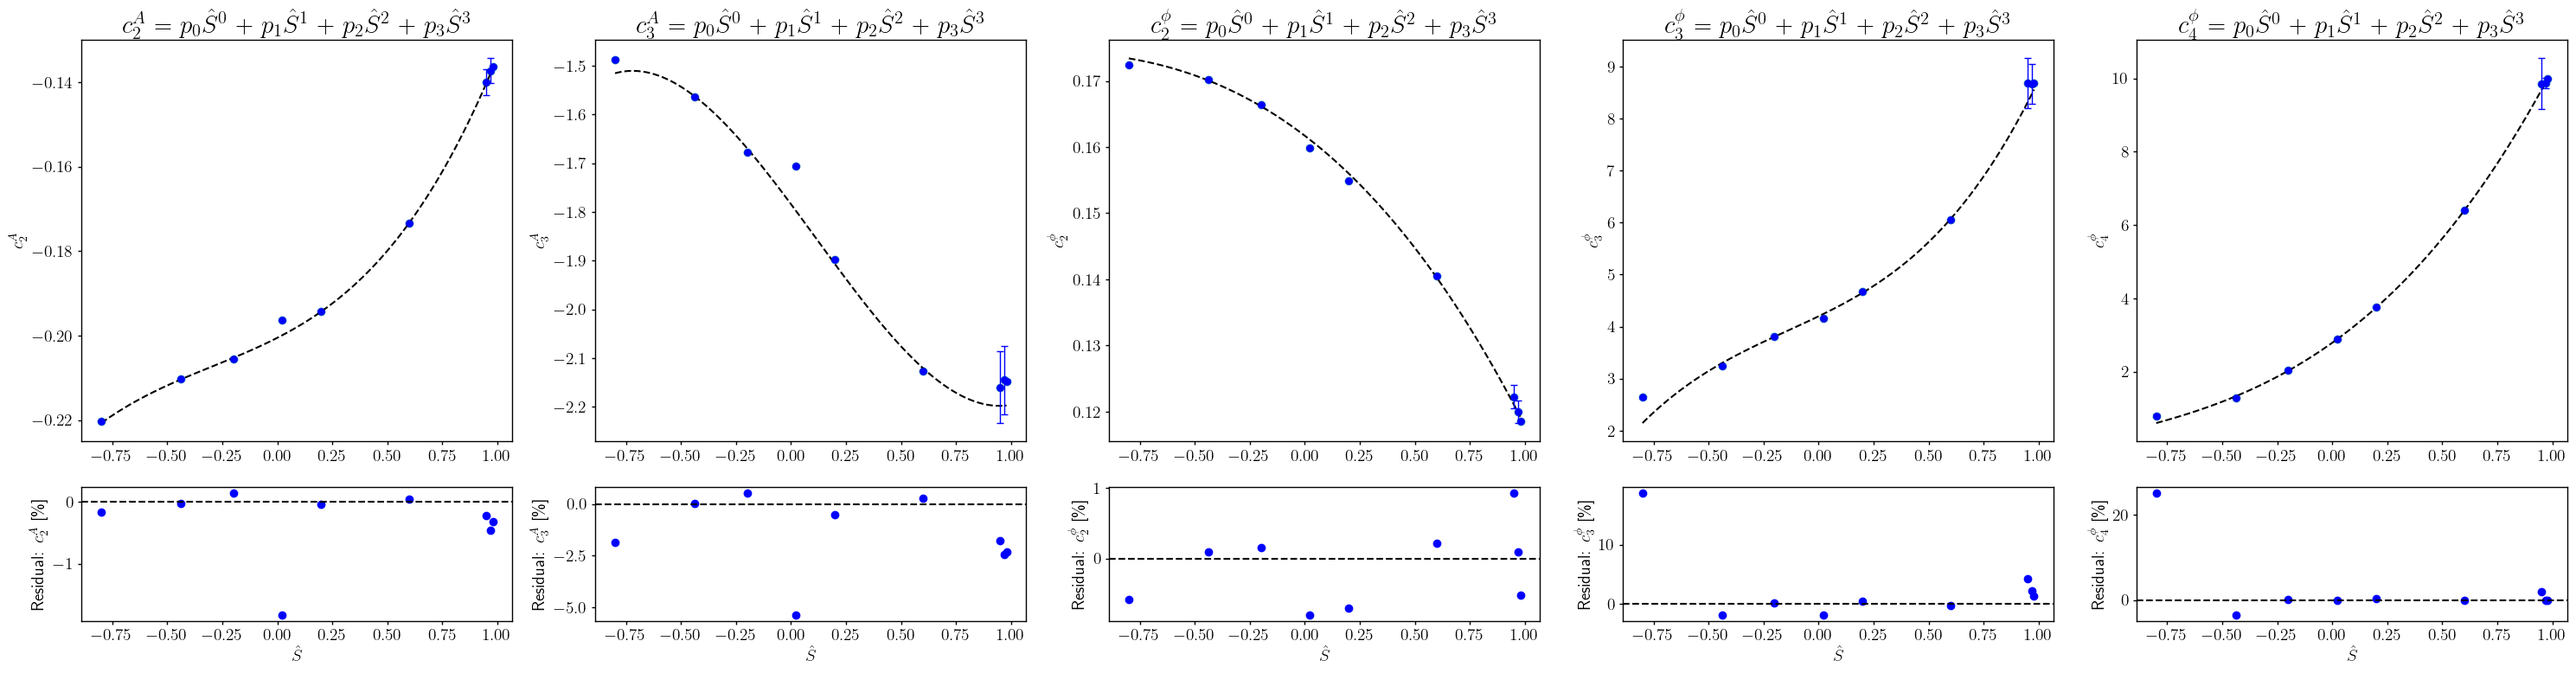

In [7]:
fig, ax = plt.subplots(2, 5, figsize=(30, 8), gridspec_kw={'height_ratios': [3, 1]})
plots, fits, errors = [c2A, c3A, c2p, c3p, c4p], [p2Achi, p3Achi, p2pchi, p3pchi, p4pchi], [c2A_err, c3A_err, c2p_err, c3p_err, c4p_err]
ylabels = ['$c_2^A$', '$c_3^A$', '$c_2^{\\phi}$', '$c_3^{\\phi}$', '$c_4^{\\phi}$']
chispace = np.linspace(np.min(S_hat), np.max(S_hat), 100)
for i, (a_0, a_1, y, e, f, ylabel) in enumerate(zip(ax[0, :], ax[1, :],plots, errors, fits, ylabels)):    
    a_0.plot(chispace, np.polyval(f, chispace), label='Fit', color='k', linestyle='--')
    a_0.errorbar(S_hat, y, yerr=e, fmt='o', color='b', markersize=5, elinewidth=1, capsize=3)
    a_0.scatter(S_hat, y)
    a_0.set_ylabel(ylabel)
    poly_terms = []
    for j in range(len(f)):
        term = "$p_{{{}}} \\hat{{S}}^{{{}}}$".format(j, j)
        poly_terms.append(term)
    poly_string = " $+$ ".join(poly_terms)
    a_0.set_title("{} = {}".format(ylabel, poly_string))
    residual = 100*(y - np.polyval(f, S_hat))/y
    a_1.axhline(0, color='k', linestyle='--')
    a_1.scatter(S_hat, residual, color='b', marker='o')
    a_1.set_xlabel('$\\hat{{S}}$')
    a_1.set_ylabel('Residual: {ylabel} [\\%]'.format(ylabel=ylabel))
plt.tight_layout()
plt.show()

In [8]:
def get_mismatches(filename):
    mismatch = np.zeros(len(sxs_ids))
    for i, sxs_id in enumerate(sxs_ids):
        try:
            mismatch_row = np.genfromtxt(f'../../output/nc_qc_fits/{filename}/SXS_{sxs_id}/Algorithm/Mismatch/Mismatch_M_60_dL_410_t_s_0.0M_wDX_0.0Hz_wSX_0.0Hz_k_0.0_satDX_1.0_satSD_1.0_NFFT_869565.txt',
                                        dtype=None, names=True, encoding='utf-8', comments='#')
            mismatch_real = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'real']['Mismatch'][0]
            mismatch_imag = mismatch_row[mismatch_row['CI'] == 50][mismatch_row[mismatch_row['CI'] == 50]['Strain_data'] == 'imag']['Mismatch'][0]
            mismatch[i] = np.sqrt(mismatch_real**2 + mismatch_imag**2)
        except:
            continue
    mismatch = mismatch[mismatch!=0]
    return mismatch

mismatch_global_nc = get_mismatches('nc_global_fits_sxs_equal-mass')
mismatch_local_nc = get_mismatches('nc_fits_sxs_equal-mass')
mismatch_global_qc = get_mismatches('qc_global_fits_sxs_equal-mass')
mismatch_local_qc = get_mismatches('qc_fits_sxs_equal-mass')
mismatch_global_qc_0 = get_mismatches('qc_global_fits_sxs_equal-mass_0')

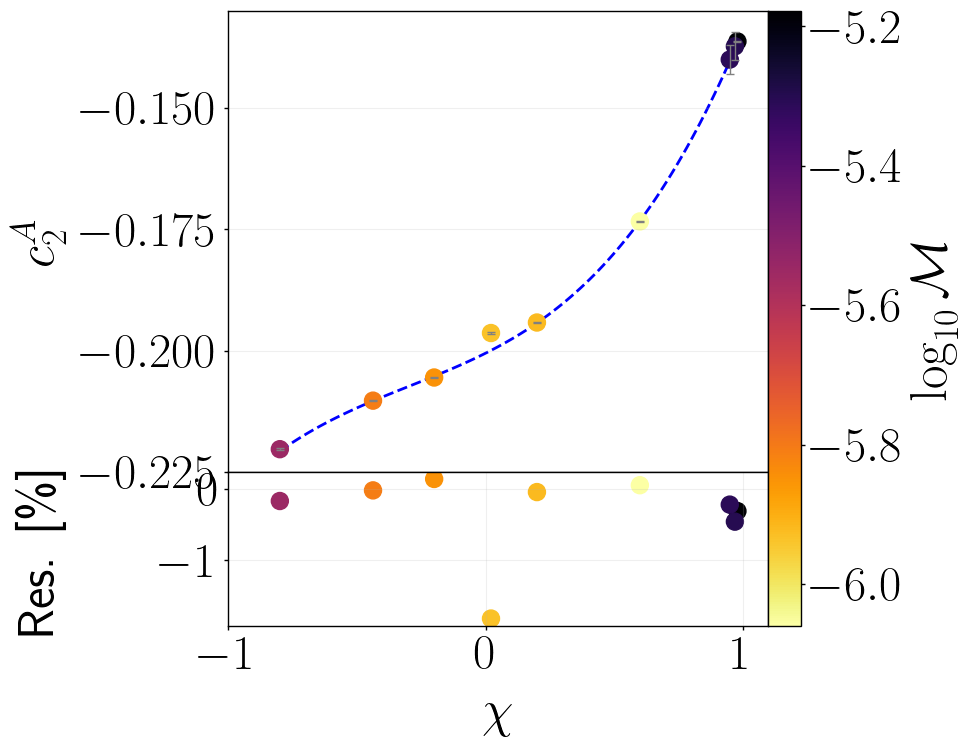

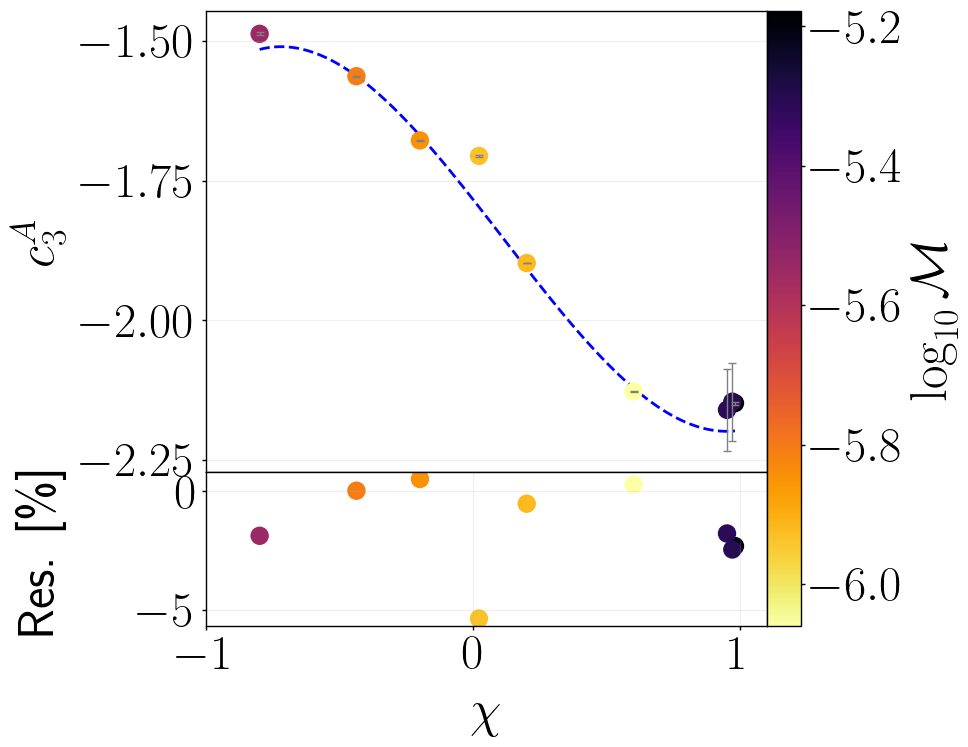

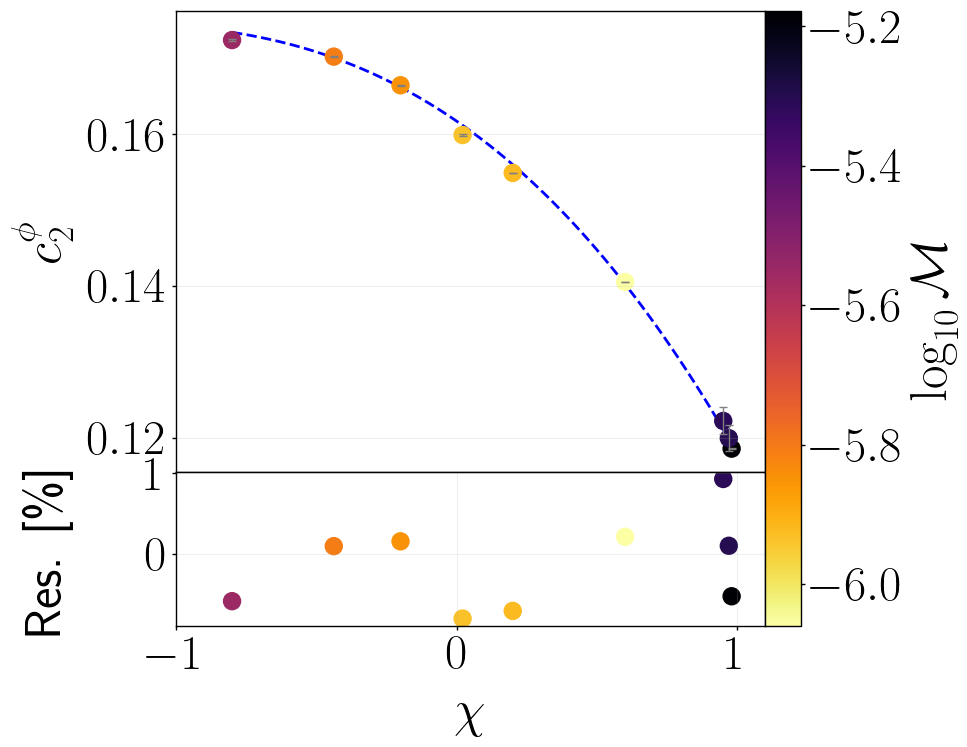

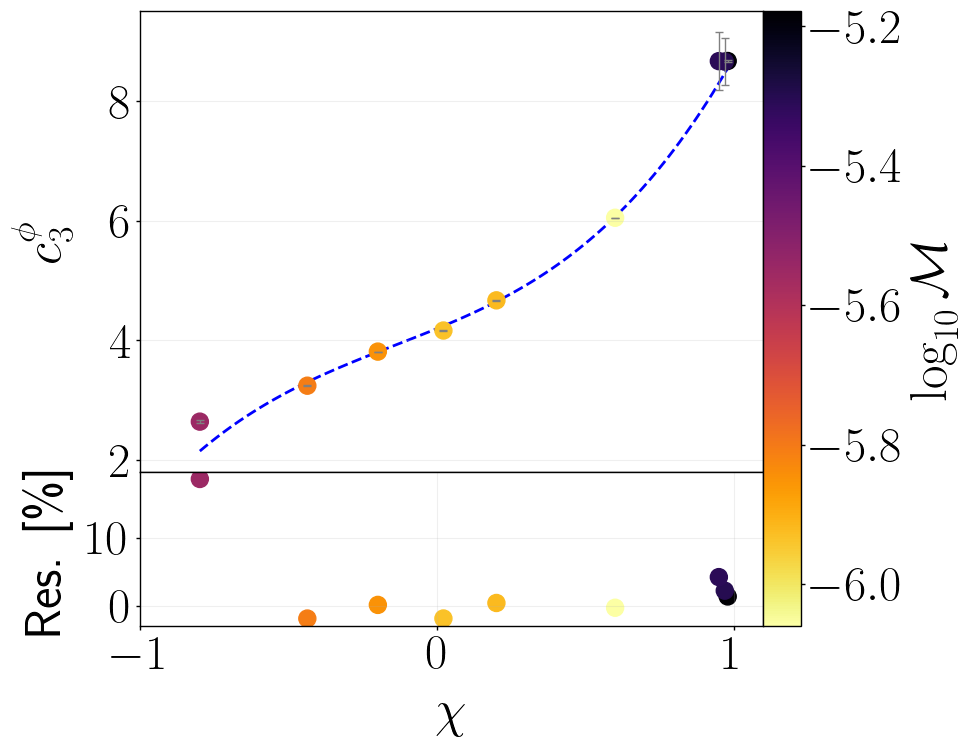

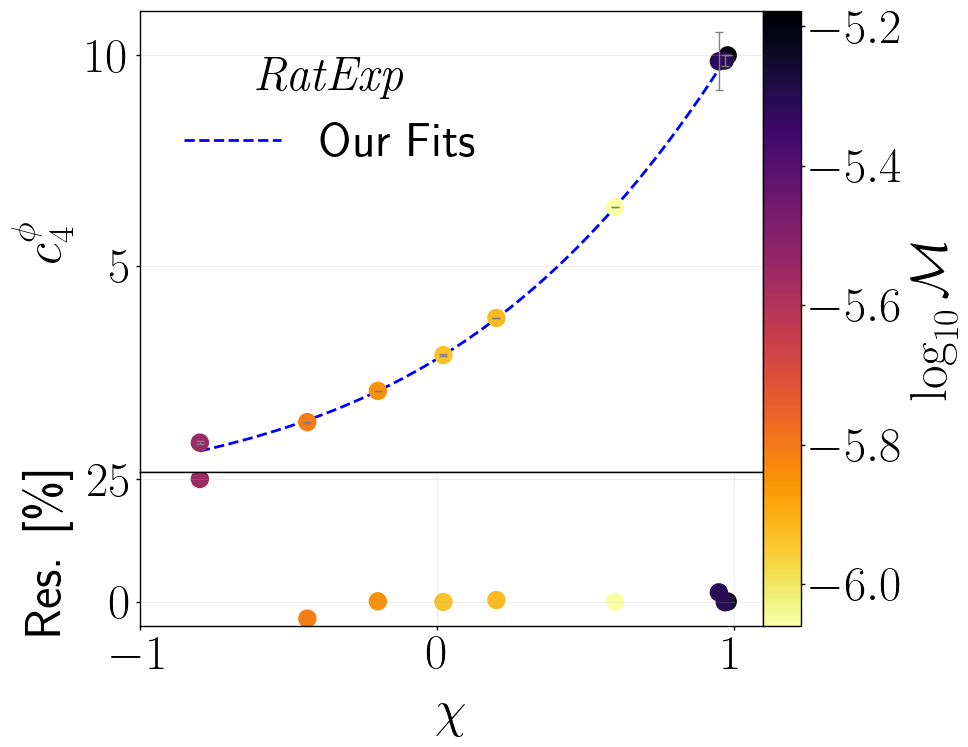

In [9]:
lw_fit      = 2
size_labels = 37
maker_size  = 150
ticklabelsize = 35
legendlabelsize = 35
ls_fit      = 'dashed'
color_fit   = 'blue'
palette_fig = 'inferno_r'
for coeff, err, label, coeff_fit, lab in zip([c2A, c3A, c2p, c3p, c4p], [c2A_err, c3A_err, c2p_err, c3p_err, c4p_err], ylabels, fits, ['c2A', 'c3A', 'c2p', 'c3p', 'c4p']):
    fig = plt.figure(figsize=(9*1.1,7*1.1))
    gs = fig.add_gridspec(nrows=4, ncols=2, width_ratios=[1, 0.06], hspace=0., wspace=0.)
    ax1 = fig.add_subplot(gs[:3, 0])
    ax2 = fig.add_subplot(gs[3, 0])
    cax = fig.add_subplot(gs[:, 1])
    ax1.errorbar(S_hat, coeff, yerr=err, markersize=5, linewidth=1, capsize=3, fmt='None', color='gray')
    sc = ax1.scatter(x=S_hat, y=coeff, c=np.log10(mismatch_local_nc), cmap=palette_fig, s=maker_size)
    ax1.plot(chispace, np.polyval(coeff_fit, chispace), c=color_fit, ls=ls_fit, lw=lw_fit, zorder=-1, label=r'Our Fits')
    ax1.grid(alpha=0.2)
    ax1.set_ylabel(label, fontsize=size_labels, labelpad=10)
    ax2.scatter(x=S_hat, y=100 * (coeff - np.polyval(coeff_fit, S_hat)) / coeff, c=np.log10(mismatch_local_nc), cmap=palette_fig, s=maker_size)
    cb = fig.colorbar(sc, cax=cax, label=r'$\log_{10}\mathcal{M}$')
    cb.ax.tick_params(labelsize=ticklabelsize)
    cb.ax.yaxis.label.set_size(size_labels)
    ax2.grid(alpha=0.2)
    ax2.set_ylabel(r'Res. [\%]', fontsize=size_labels, labelpad=10)
    ax2.set_xlabel('$\\chi$', fontsize=size_labels, labelpad=10)
    ax1.set_xticks([])
    ax1.set_xlim([-1,1.1])
    ax2.set_xlim([-1,1.1])
    if coeff is c4p:
        ax1.legend(fontsize=legendlabelsize, loc='best', title=r'$\it{RatExp}$', title_fontsize=legendlabelsize)
    ax1.tick_params(axis='both', which='major', labelsize=ticklabelsize)
    ax2.tick_params(axis='both', which='major', labelsize=ticklabelsize)
    fig.align_ylabels()
    plt.tight_layout()
    plt.savefig(f"{lab}_fit_sxs_chi.pdf", bbox_inches='tight')
    plt.show()

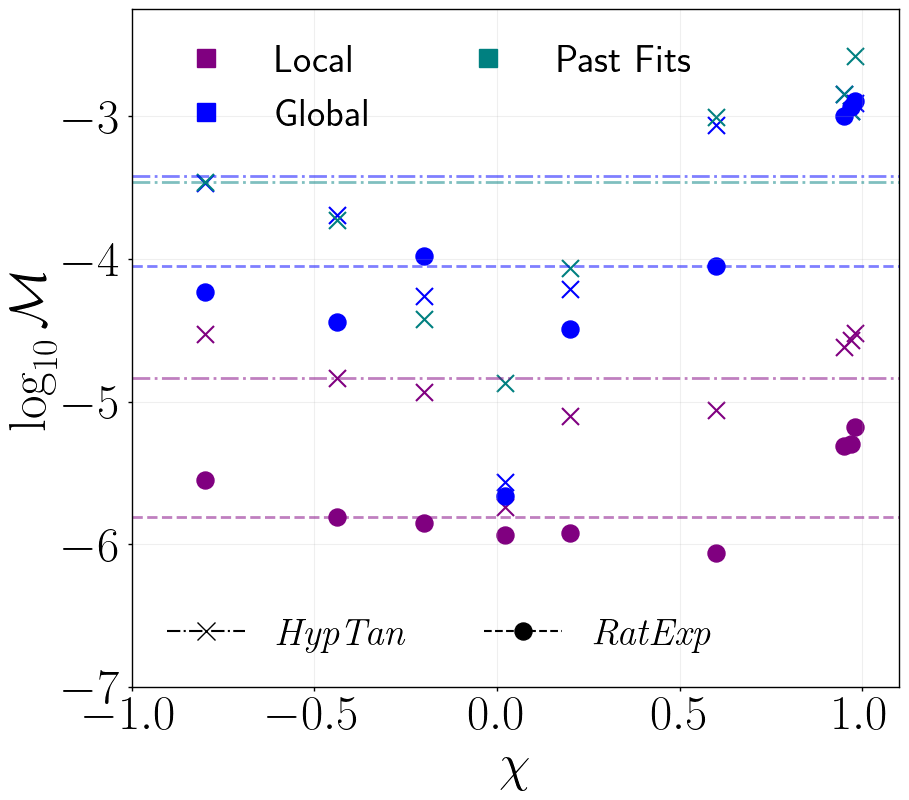

In [10]:
size_labels     = 37
maker_size      = 150
ticklabelsize   = 35
legendlabelsize = 28
lw_ref          = 2
alpha_data      = 1

color_palette = {
    'primary':   'purple',
    'secondary': 'blue',
    'tertiary':  'teal',
}

fig = plt.figure(figsize=(9*1.1, 8*1.1))
ax = fig.add_subplot()

marker_size = np.sqrt(maker_size)

ax.scatter(S_hat, np.log10(mismatch_local_qc), marker='x', color=color_palette['primary'], s=maker_size, alpha=alpha_data)
ax.scatter(S_hat, np.log10(mismatch_global_qc), marker='x', color=color_palette['secondary'], s=maker_size, alpha=alpha_data)
ax.scatter(S_hat, np.log10(mismatch_global_qc_0), marker='x', color=color_palette['tertiary'], s=maker_size, alpha=alpha_data)

ax.scatter(S_hat, np.log10(mismatch_local_nc), marker='o', color=color_palette['primary'], s=maker_size, alpha=alpha_data)
ax.scatter(S_hat, np.log10(mismatch_global_nc), marker='o', color=color_palette['secondary'], s=maker_size, alpha=alpha_data)

ax.axhline(np.log10(np.median(mismatch_local_qc)), color=color_palette['primary'], linestyle='-.', linewidth=lw_ref, alpha=0.5)
ax.axhline(np.log10(np.median(mismatch_global_qc))+0.05, color=color_palette['secondary'], linestyle='-.', linewidth=lw_ref, alpha=0.5)
ax.axhline(np.log10(np.median(mismatch_global_qc_0)), color=color_palette['tertiary'], linestyle='-.', linewidth=lw_ref, alpha=0.5)

ax.axhline(np.log10(np.median(mismatch_local_nc)), color=color_palette['primary'], linestyle='--', linewidth=lw_ref, alpha=0.5)
ax.axhline(np.log10(np.median(mismatch_global_nc)), color=color_palette['secondary'], linestyle='--', linewidth=lw_ref, alpha=0.5)
ax.grid(alpha=0.2)

ax.set_ylabel(r'$\log_{10}\mathcal{M}$', fontsize=size_labels)
ax.set_xlabel(r'$\chi$', fontsize=size_labels)
ax.set_xlim([-1,1.1])
ax.tick_params(axis='both', which='major', labelsize=ticklabelsize)
marker_handles = [
    Line2D([], [], color='k', marker='x', linestyle='-.', 
           markersize=marker_size, label=r'$\it{HypTan}$'),
    Line2D([], [], color='k', marker='o', linestyle='--', 
           markersize=marker_size, label=r'$\it{RatExp}$'),
]
color_handles = [
    Line2D([], [], color=color_palette['primary'], marker='s', linestyle='None', markersize=marker_size, label='Local'),
    Line2D([], [], color=color_palette['secondary'], marker='s', linestyle='None', markersize=marker_size, label='Global'),
    Line2D([], [], color=color_palette['tertiary'], marker='s', linestyle='None', markersize=marker_size, label='Past Fits'),
]

ax.set(ylim=(-7, -2.25))
legend_markers = ax.legend(handles=marker_handles, fontsize=legendlabelsize, loc='lower left', ncol=2)
ax.add_artist(legend_markers)

legend_colors = ax.legend(handles=color_handles, fontsize=legendlabelsize, loc='upper left', ncol=2)

plt.savefig("mismatch_sxs_chi.pdf", bbox_inches='tight')
plt.show()